> **Repository note.** Development notebook: initial geometric intuition and pilot.
> This notebook is preserved with executed outputs from the research run. Large embedding caches and third-party datasets are intentionally not bundled. See `REPRODUCIBILITY.md` at the repository root.


# Semantic Disambiguation Geometry
## Does disambiguation contract a concept cloud, separate senses, or enrich contextual variation?

### Research question

\[
\boxed{
\text{How does the geometry of contextualized word representations evolve as semantic uncertainty is progressively reduced by context?}
}
\]

We test three competing geometric hypotheses for ambiguous words such as **bank**:

1. **Contraction**
   \[
   H(S\mid C)\downarrow,\qquad V_{\text{within}}\downarrow
   \]

2. **Separation**
   \[
   H(S\mid C)\downarrow,\qquad D_{\text{between}}\uparrow
   \]

3. **Contextual enrichment**
   \[
   H(S\mid C)\downarrow,\qquad
   D_{\text{between}}\uparrow,\qquad
   V_{\text{within}}\uparrow
   \]

The key distinction is:

\[
\boxed{
\text{semantic uncertainty reduction} \neq \text{geometric contraction}
}
\]

This notebook is a **research pilot**. It freezes a pretrained contextual encoder and analyzes its geometry; it does not train a new representation.

## Literature-grounded motivation

Prior work separately establishes that:

- contextual token representations vary strongly across contexts;
- context helps resolve lexical ambiguity;
- embeddings of the **same sense** can still vary substantially across contexts;
- contextual word types can be studied as point clouds;
- context-induced displacement has structured geometry.

The empirical tension is whether **controlled accumulation of disambiguating evidence** is realized geometrically by contraction, separation, or enrichment.

### Closest literature

- Ethayarajh (EMNLP 2019), *How Contextual are Contextualized Word Representations?*
- Pimentel et al. (EMNLP 2020), lexical ambiguity and contextual informativeness
- Yenicelik et al. (BlackboxNLP 2020), polysemy geometry in BERT
- Trott & Bergen (ACL 2021), RAW-C
- Wang & Zhang (2022/2023), *Lost in Context? On the Sense-wise Variance of Contextualized Word Embeddings*
- Yamagiwa & Shimodaira (COLING 2025), contextual-embedding variance decomposition
- Riviere et al. (NAACL 2025), layerwise disambiguation trajectories
- Nagata & Tanaka-Ishii (ACL 2025), contextual embedding clouds and semantic breadth
- Ehara (ACL 2026), statistical testing for semantic breadth
- Hu, Niu & Varma (2026), *Language Models Represent and Transform Concepts with Shared Geometry*
- Vives et al. (Nature Human Behaviour 2023), semantic **expansion** as an uncertainty-resolution mechanism

### Methodological rule

We keep four quantities separate:

- **sense uncertainty**,
- **directional shift**,
- **within-sense dispersion**,
- **between-sense separation**.

Raw variance alone is not interpreted as “meaning uncertainty”.

In [1]:
# Kaggle/Colab setup
!pip -q install "datasets>=2.18,<4" "transformers>=4.43,<5" accelerate scipy scikit-learn pandas pyarrow tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.


In [2]:
import os
import math
import json
import random
import hashlib
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from scipy.optimize import minimize_scalar
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr, wilcoxon

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


## Configuration

`RUN_MODE="pilot"` is intended for the first Kaggle T4 run.

Recommended workflow:

1. run the pilot;
2. inspect whether the curves show a real phenomenon;
3. only then switch to `RUN_MODE="full"` or add more models.

The main encoder is **BERT-base-uncased** because the project analyzes **contextual target-token embeddings**, not pooled sentence embeddings.

In [3]:
RUN_MODE = "pilot"   # "pilot" or "full"

DATASET_ID = "kiamehr74/CoarseWSD-20"
MODEL_NAME = "bert-base-uncased"

ALL_WORDS = [
    "apple", "arm", "bank", "bass", "bow",
    "chair", "club", "crane", "deck", "digit",
    "hood", "java", "mole", "pitcher", "pound",
    "seal", "spring", "square", "trunk", "yard",
]

if RUN_MODE == "pilot":
    WORDS = ["bank", "bass", "crane", "java", "mole", "spring"]
    MAX_TRAIN_PER_SENSE = 250
    MAX_TEST_PER_SENSE = 100
    ENCODE_BATCH_SIZE = 64
else:
    WORDS = ALL_WORDS
    MAX_TRAIN_PER_SENSE = 500
    MAX_TEST_PER_SENSE = 150
    ENCODE_BATCH_SIZE = 64

# BERT-base: hidden-state 0 is the embedding layer; 1..12 are transformer blocks.
LAYERS_TO_SAVE = [4, 8, 12]
MAIN_LAYER = 12

# Number of non-target context tokens revealed.
REVEAL_COUNTS = [0, 1, 2, 4, 8, 16]
STRATEGIES = ["gold_pmi", "local", "random"]

# Crop long Wikipedia sentences around the target word.
MAX_WORDS = 96

OUTPUT_DIR = Path("semantic_disambiguation_geometry_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("mode:", RUN_MODE)
print("words:", WORDS)
print("layers:", LAYERS_TO_SAVE)

mode: pilot
words: ['bank', 'bass', 'crane', 'java', 'mole', 'spring']
layers: [4, 8, 12]


## Data: CoarseWSD-20

CoarseWSD-20 contains **20 ambiguous nouns**, each with 2–5 coarse senses and official train/test splits.

Each example includes:

- the sentence,
- the gold coarse sense,
- the whitespace-token index of the target word.

That target index lets us extract the contextual representation of the ambiguous token itself.

In [4]:
def crop_around_target(tokens, target_idx, max_words=96):
    if len(tokens) <= max_words:
        return tokens, target_idx

    half = max_words // 2
    left = max(0, target_idx - half)
    right = min(len(tokens), left + max_words)
    left = max(0, right - max_words)

    cropped = tokens[left:right]
    new_idx = target_idx - left
    return cropped, new_idx


def stratified_cap(df, per_sense, seed=SEED):
    parts = []
    for _, g in df.groupby("label", sort=True):
        n = min(len(g), per_sense)
        parts.append(g.sample(n=n, random_state=seed))
    return pd.concat(parts, ignore_index=True)


def load_word_config(word):
    # One HF config per ambiguous word.
    ds = load_dataset(DATASET_ID, word, trust_remote_code=True)
    label_names = ds["train"].features["label"].names

    frames = []
    for split in ["train", "test"]:
        d = ds[split].to_pandas()
        d["word"] = word
        d["split"] = split
        d["sense_name"] = d["label"].map(dict(enumerate(label_names)))

        token_lists = []
        new_indices = []
        valid = []

        for _, row in d.iterrows():
            toks = str(row["sentence"]).split()
            idx = int(row["idx"])

            if not (0 <= idx < len(toks)):
                valid.append(False)
                token_lists.append([])
                new_indices.append(-1)
                continue

            toks2, idx2 = crop_around_target(toks, idx, MAX_WORDS)
            token_lists.append(toks2)
            new_indices.append(idx2)

            target_surface = toks2[idx2].lower().strip('.,;:!?()[]{}\"')
            valid.append(
                word.lower() in target_surface
                or target_surface in word.lower()
            )

        d["tokens"] = token_lists
        d["target_idx"] = new_indices
        d["target_check"] = valid
        d["example_id"] = [f"{word}:{split}:{i}" for i in range(len(d))]
        frames.append(d)

    return pd.concat(frames, ignore_index=True)


all_df = pd.concat(
    [load_word_config(w) for w in tqdm(WORDS, desc="loading CoarseWSD-20")],
    ignore_index=True,
)

print(all_df.shape)
display(
    all_df.groupby(["word", "split", "sense_name"])
          .size()
          .rename("n")
          .reset_index()
          .head(30)
)
print("target-index sanity-check rate:", all_df["target_check"].mean())

loading CoarseWSD-20:   0%|          | 0/6 [00:00<?, ?it/s]

CoarseWSD-20.py: 0.00B [00:00, ?B/s]

0000.parquet:   0%|          | 0.00/128k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/52.5k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1107 [00:00<?, ? examples/s]

...

Generating train split:   0%|          | 0/1064 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/457 [00:00<?, ? examples/s]

(15295, 10)


,word,split,sense_name,n
0,bank,test,bank_bank,433
1,bank,test,bank_bank_(geography),22
2,bank,train,bank_bank,1061
3,bank,train,bank_bank_(geography),46
4,bass,test,bass_bass_(voice_type),298
5,bass,test,bass_bass_guitar,1005
6,bass,test,bass_double_bass,88
7,bass,train,bass_bass_(voice_type),609
8,bass,train,bass_bass_guitar,2356
9,bass,train,bass_double_bass,208


target-index sanity-check rate: 1.0


In [5]:
train_df = stratified_cap(
    all_df[all_df["split"] == "train"].copy(),
    MAX_TRAIN_PER_SENSE,
)

test_df = stratified_cap(
    all_df[all_df["split"] == "test"].copy(),
    MAX_TEST_PER_SENSE,
)

print("train sampled:", len(train_df))
print("test sampled :", len(test_df))

display(
    test_df.groupby(["word", "sense_name"])
           .size()
           .rename("n")
           .reset_index()
)

train sampled: 854
test sampled : 343


,word,sense_name,n
0,bank,bank_bank,18
1,bank,bank_bank_(geography),2
2,bass,bass_bass_(voice_type),21
3,bass,bass_bass_guitar,38
4,bass,bass_double_bass,38
5,crane,crane_crane_(bird),4
6,crane,crane_crane_(machine),3
7,java,java_java,32
8,java,java_java_(programming_language),57
9,mole,mole_mole_(animal),3


## Experimental manipulation: progressively reveal context

A major confound is:

\[
\text{more tokens} \neq \text{more disambiguating information}.
\]

The main protocol holds sentence length fixed with `[MASK]` and reveals the same **number** of context tokens under three strategies.

### `gold_pmi` — oracle disambiguating evidence

Using **training data only**, estimate how strongly each context token is associated with an example's gold sense:

\[
\operatorname{score}(t,s)
=
\log \frac{P(t\mid s)}{P(t)}.
\]

At test time, the gold sense is used only to construct a controlled intervention.  
This is **not a deployable WSD system**. It asks:

> what happens geometrically if we deliberately reveal evidence increasingly diagnostic of the true sense?

### `local`

Reveal nearest context tokens first.

### `random`

Reveal a deterministic random ordering.

`local` and `random` are matched-token-count controls.

In [6]:
PUNCT = set(".,;:!?()[]{}\"'`-–—")


def norm_token(t):
    return t.lower().strip(".,;:!?()[]{}\"'`")


def is_punctuation_token(t):
    s = t.strip()
    return len(s) > 0 and all(ch in PUNCT for ch in s)


def build_pmi_tables(df, alpha=0.5):
    tables = {}

    for word, g in df.groupby("word"):
        n_all = len(g)
        labels = sorted(g["label"].unique())

        all_dfreq = Counter()
        sense_dfreq = {int(lab): Counter() for lab in labels}
        n_sense = Counter(g["label"].astype(int))

        for _, row in g.iterrows():
            target_idx = int(row["target_idx"])
            seen = set()

            for i, tok in enumerate(row["tokens"]):
                if i == target_idx:
                    continue
                nt = norm_token(tok)
                if not nt or is_punctuation_token(tok):
                    continue
                if nt == word.lower():
                    continue
                seen.add(nt)

            all_dfreq.update(seen)
            sense_dfreq[int(row["label"])].update(seen)

        vocab = set(all_dfreq)
        word_table = {}

        for lab in labels:
            lab = int(lab)
            scores = {}
            for tok in vocab:
                p_ts = (sense_dfreq[lab][tok] + alpha) / (n_sense[lab] + 2 * alpha)
                p_t = (all_dfreq[tok] + alpha) / (n_all + 2 * alpha)
                scores[tok] = math.log(p_ts / p_t)
            word_table[lab] = scores

        tables[word] = word_table

    return tables


PMI_TABLES = build_pmi_tables(train_df)
print("PMI tables built for", len(PMI_TABLES), "words")

PMI tables built for 6 words


In [7]:
def context_positions(tokens, target_idx):
    # Punctuation remains visible in every condition.
    return [
        i for i, tok in enumerate(tokens)
        if i != target_idx and not is_punctuation_token(tok)
    ]


def rank_positions(row, strategy):
    tokens = row["tokens"]
    target_idx = int(row["target_idx"])
    positions = context_positions(tokens, target_idx)

    if strategy == "local":
        return sorted(positions, key=lambda i: (abs(i - target_idx), i))

    if strategy == "random":
        key = f"{SEED}|{row['example_id']}".encode()
        seed = int(hashlib.md5(key).hexdigest()[:8], 16)
        rng = random.Random(seed)
        positions = positions.copy()
        rng.shuffle(positions)
        return positions

    if strategy == "gold_pmi":
        scores = PMI_TABLES[row["word"]][int(row["label"])]
        return sorted(
            positions,
            key=lambda i: scores.get(norm_token(tokens[i]), -999.0),
            reverse=True,
        )

    raise ValueError(strategy)


def make_masked_variant(row, strategy, reveal_k, mask_token):
    tokens = list(row["tokens"])
    target_idx = int(row["target_idx"])
    ranked = rank_positions(row, strategy)
    reveal = set(ranked[:reveal_k])

    out = []
    for i, tok in enumerate(tokens):
        if i == target_idx:
            out.append(tok)
        elif is_punctuation_token(tok):
            out.append(tok)
        elif i in reveal:
            out.append(tok)
        else:
            out.append(mask_token)

    return out, len(reveal), len(ranked)


def build_variants(df, mask_token):
    records = []

    keep_cols = [
        "example_id", "word", "label", "sense_name", "target_idx"
    ]

    for _, row in tqdm(df.iterrows(), total=len(df), desc="building reveal variants"):
        base = row.to_dict()

        for strategy in STRATEGIES:
            for order, k in enumerate(REVEAL_COUNTS):
                toks, actual, total = make_masked_variant(
                    row, strategy, k, mask_token
                )

                rec = {k2: base[k2] for k2 in keep_cols}
                rec.update({
                    "strategy": strategy,
                    "stage": str(k),
                    "stage_order": order,
                    "requested_reveal": k,
                    "actual_reveal": actual,
                    "available_context": total,
                    "tokens_variant": toks,
                })
                records.append(rec)

            rec = {k2: base[k2] for k2 in keep_cols}
            total = len(context_positions(row["tokens"], int(row["target_idx"])))
            rec.update({
                "strategy": strategy,
                "stage": "full",
                "stage_order": len(REVEAL_COUNTS),
                "requested_reveal": -1,
                "actual_reveal": total,
                "available_context": total,
                "tokens_variant": list(row["tokens"]),
            })
            records.append(rec)

    return pd.DataFrame(records)

## Frozen encoder and target-token extraction

We tokenize pre-split whitespace words with `is_split_into_words=True`.

If the ambiguous target becomes multiple subwords, the notebook averages all hidden states mapped to that original target word.

Layers 4, 8, and 12 are cached from one forward pass.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
)
model.to(DEVICE)
model.eval()

assert tokenizer.mask_token is not None, "A masked-language-model tokenizer is required."
print("mask token:", tokenizer.mask_token)
print("hidden size:", model.config.hidden_size)
print("num layers:", model.config.num_hidden_layers)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

mask token: [MASK]
hidden size: 768
num layers: 12


In [9]:
@torch.inference_mode()
def encode_target_tokens(
    token_lists,
    target_indices,
    layers=LAYERS_TO_SAVE,
    batch_size=ENCODE_BATCH_SIZE,
):
    outputs = {layer: [] for layer in layers}

    for start in tqdm(
        range(0, len(token_lists), batch_size),
        desc="encoding"
    ):
        batch_tokens = token_lists[start:start + batch_size]
        batch_targets = target_indices[start:start + batch_size]

        enc = tokenizer(
            batch_tokens,
            is_split_into_words=True,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        )

        word_ids = [
            enc.word_ids(batch_index=i)
            for i in range(len(batch_tokens))
        ]

        enc_t = {k: v.to(DEVICE) for k, v in enc.items()}
        out = model(**enc_t)
        hidden_states = out.hidden_states

        for layer in layers:
            h = hidden_states[layer]
            batch_vecs = []

            for b, target_word_idx in enumerate(batch_targets):
                positions = [
                    j for j, wid in enumerate(word_ids[b])
                    if wid == int(target_word_idx)
                ]

                if not positions:
                    vec = torch.full(
                        (model.config.hidden_size,),
                        float("nan"),
                        device=h.device,
                    )
                else:
                    vec = h[b, positions, :].mean(dim=0)

                batch_vecs.append(vec)

            batch_vecs = torch.stack(batch_vecs).float().cpu().numpy()
            outputs[layer].append(batch_vecs)

    return {
        layer: np.concatenate(chunks, axis=0)
        for layer, chunks in outputs.items()
    }


def l2_normalize_rows(x, eps=1e-12):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, eps)

## Full-context sense prototypes

Sense labels provide a semantic anchor.

For each word and layer:

1. split sampled training examples into **prototype** and **calibration** subsets;
2. encode target tokens in full natural context;
3. average normalized embeddings within each sense;
4. fit one temperature scalar on the calibration subset.

For contextual vector \(h\):

\[
p(s\mid h)
=
\operatorname{softmax}
\left(
\frac{\cos(h,\mu_s)}{T}
\right).
\]

Normalized prototype entropy:

\[
H_{\text{proto}}
=
\frac{-\sum_s p(s\mid h)\log p(s\mid h)}
{\log |\mathcal S|}.
\]

This is a **model uncertainty proxy**, not a claim about human subjective entropy.

In [10]:
def assign_proto_calib_split(df, calib_frac=0.2):
    out = df.copy()
    out["proto_split"] = "prototype"

    rng = np.random.default_rng(SEED)

    for (_, _), idxs in out.groupby(["word", "label"]).groups.items():
        idxs = np.array(list(idxs))
        if len(idxs) < 3:
            continue
        n_cal = max(1, int(round(len(idxs) * calib_frac)))
        n_cal = min(n_cal, len(idxs) - 1)
        chosen = rng.choice(idxs, size=n_cal, replace=False)
        out.loc[chosen, "proto_split"] = "calibration"

    return out


train_embed_df = assign_proto_calib_split(
    train_df.reset_index(drop=True)
)

train_embeddings = encode_target_tokens(
    train_embed_df["tokens"].tolist(),
    train_embed_df["target_idx"].astype(int).tolist(),
)

for layer in LAYERS_TO_SAVE:
    train_embeddings[layer] = l2_normalize_rows(
        train_embeddings[layer]
    )

print({k: v.shape for k, v in train_embeddings.items()})

encoding:   0%|          | 0/14 [00:00<?, ?it/s]

{4: (854, 768), 8: (854, 768), 12: (854, 768)}


In [11]:
def softmax_np(logits):
    z = logits - logits.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)


def nll_for_temperature(logT, logits, y_index):
    T = math.exp(logT)
    p = softmax_np(logits / T)
    p_true = p[np.arange(len(p)), y_index]
    return -np.mean(np.log(np.clip(p_true, 1e-12, 1.0)))


prototype_store = {}

for word in WORDS:
    word_rows = train_embed_df[train_embed_df["word"] == word]
    label_values = sorted(word_rows["label"].astype(int).unique())
    label_to_col = {
        lab: i for i, lab in enumerate(label_values)
    }

    for layer in LAYERS_TO_SAVE:
        emb = train_embeddings[layer]

        proto_mask = (
            (train_embed_df["word"] == word)
            & (train_embed_df["proto_split"] == "prototype")
        )

        protos = []
        for lab in label_values:
            m = proto_mask & (train_embed_df["label"].astype(int) == lab)
            vec = emb[m.to_numpy()].mean(axis=0)
            vec = vec / max(np.linalg.norm(vec), 1e-12)
            protos.append(vec)

        protos = np.stack(protos)

        calib_mask = (
            (train_embed_df["word"] == word)
            & (train_embed_df["proto_split"] == "calibration")
        )
        calib_idx = np.where(calib_mask.to_numpy())[0]

        calib_emb = emb[calib_idx]
        calib_y_raw = (
            train_embed_df.iloc[calib_idx]["label"]
            .astype(int)
            .to_numpy()
        )
        calib_y = np.array(
            [label_to_col[y] for y in calib_y_raw]
        )

        logits = calib_emb @ protos.T

        opt = minimize_scalar(
            nll_for_temperature,
            bounds=(-4.0, 2.0),
            args=(logits, calib_y),
            method="bounded",
        )
        temperature = float(math.exp(opt.x))

        prototype_store[(word, layer)] = {
            "labels": label_values,
            "label_to_col": label_to_col,
            "prototypes": protos,
            "temperature": temperature,
        }

print("prototype sets:", len(prototype_store))
for key in list(prototype_store)[:6]:
    print(key, "T =", round(prototype_store[key]["temperature"], 4))

prototype sets: 18
('bank', 4) T = 0.0183
('bank', 8) T = 0.0184
('bank', 12) T = 0.0183
('bass', 4) T = 0.0183
('bass', 8) T = 0.0183
('bass', 12) T = 0.0188


## Generate and encode progressive context variants

This is the expensive cell.

The pilot produces tens of thousands of masked-context examples.  
On a Kaggle T4 this is intended to be a single manageable run.

In [12]:
variant_df = build_variants(
    test_df.reset_index(drop=True),
    tokenizer.mask_token,
)

print("variants:", len(variant_df))
display(variant_df.head())

variant_embeddings = encode_target_tokens(
    variant_df["tokens_variant"].tolist(),
    variant_df["target_idx"].astype(int).tolist(),
)

for layer in LAYERS_TO_SAVE:
    variant_embeddings[layer] = l2_normalize_rows(
        variant_embeddings[layer]
    )

print({k: v.shape for k, v in variant_embeddings.items()})

building reveal variants:   0%|          | 0/343 [00:00<?, ?it/s]

variants: 7203


,example_id,word,label,sense_name,target_idx,strategy,stage,stage_order,requested_reveal,actual_reveal,available_context,tokens_variant
0,java:test:1850,java,0,java_java,6,gold_pmi,0,0,0,0,13,"[[MASK], [MASK], [MASK], [MASK], [MASK], [MASK..."
1,java:test:1850,java,0,java_java,6,gold_pmi,1,1,1,1,13,"[september, [MASK], [MASK], [MASK], [MASK], [M..."
2,java:test:1850,java,0,java_java,6,gold_pmi,2,2,2,2,13,"[september, [MASK], magnitude, [MASK], [MASK],..."
3,java:test:1850,java,0,java_java,6,gold_pmi,4,3,4,4,13,"[september, [MASK], magnitude, [MASK], earthqu..."
4,java:test:1850,java,0,java_java,6,gold_pmi,8,4,8,8,13,"[september, [MASK], magnitude, [MASK], earthqu..."


encoding:   0%|          | 0/113 [00:00<?, ?it/s]

{4: (7203, 768), 8: (7203, 768), 12: (7203, 768)}


## Instance-level uncertainty diagnostics

For every context stage:

- nearest-prototype WSD accuracy,
- normalized sense entropy,
- gold-vs-best-other cosine margin.

These measure **sense resolution**.

They are deliberately separate from cloud-spread metrics.

In [13]:
instance_metric_frames = []

for layer in LAYERS_TO_SAVE:
    emb = variant_embeddings[layer]

    for word in WORDS:
        idxs = np.where(
            (variant_df["word"] == word).to_numpy()
        )[0]

        if len(idxs) == 0:
            continue

        info = prototype_store[(word, layer)]
        labels = info["labels"]
        label_to_col = info["label_to_col"]
        protos = info["prototypes"]
        T = info["temperature"]

        x = emb[idxs]
        logits = x @ protos.T
        p = softmax_np(logits / T)

        gold_raw = (
            variant_df.iloc[idxs]["label"]
            .astype(int)
            .to_numpy()
        )
        gold_col = np.array(
            [label_to_col[y] for y in gold_raw]
        )

        pred_col = logits.argmax(axis=1)
        pred_raw = np.array([labels[c] for c in pred_col])

        entropy = -(
            p * np.log(np.clip(p, 1e-12, 1.0))
        ).sum(axis=1)
        entropy = entropy / math.log(len(labels))

        gold_sim = logits[
            np.arange(len(logits)),
            gold_col
        ]
        tmp = logits.copy()
        tmp[np.arange(len(tmp)), gold_col] = -np.inf
        best_other = tmp.max(axis=1)
        margin = gold_sim - best_other

        f = variant_df.iloc[idxs][[
            "example_id", "word", "label", "sense_name",
            "strategy", "stage", "stage_order",
            "requested_reveal", "actual_reveal",
            "available_context"
        ]].copy()

        f["layer"] = layer
        f["pred_label"] = pred_raw
        f["correct"] = (pred_raw == gold_raw).astype(float)
        f["sense_entropy"] = entropy
        f["gold_margin"] = margin

        instance_metric_frames.append(f)

instance_metrics = pd.concat(
    instance_metric_frames,
    ignore_index=True,
)

display(instance_metrics.head())

,example_id,word,label,sense_name,strategy,stage,stage_order,requested_reveal,actual_reveal,available_context,layer,pred_label,correct,sense_entropy,gold_margin
0,bank:test:149,bank,0,bank_bank,gold_pmi,0,0,0,0,45,4,0,1.0,0.000159,0.213329
1,bank:test:149,bank,0,bank_bank,gold_pmi,1,1,1,1,45,4,0,1.0,0.000126,0.217948
2,bank:test:149,bank,0,bank_bank,gold_pmi,2,2,2,2,45,4,0,1.0,0.000040,0.240771
3,bank:test:149,bank,0,bank_bank,gold_pmi,4,3,4,4,45,4,0,1.0,0.000126,0.217957
4,bank:test:149,bank,0,bank_bank,gold_pmi,8,4,8,8,45,4,0,1.0,0.000065,0.231106


## Geometry metrics

### Within-sense dispersion

\[
V_{\text{within}}
=
\frac1{|\mathcal S|}
\sum_s
\mathbb E_{i<j;\,S_i=S_j=s}
[1-\cos(h_i,h_j)].
\]

Pairwise distances are rotation-invariant, so moving an entire cloud's mean direction is not itself counted as contraction.

### Between-sense separation

\[
D_{\text{between}}
=
\mathbb E_{s<t}
[1-\cos(\mu_s,\mu_t)].
\]

### Separation ratio

\[
R_{\text{sep}}
=
\frac{D_{\text{between}}}
{V_{\text{within}}+\epsilon}.
\]

### Effective rank

For centered embeddings with singular-value energy proportions \(p_i\):

\[
r_{\text{eff}}
=
\exp\left(-\sum_i p_i\log p_i\right).
\]

Effective rank is descriptive, not a literal count of semantic dimensions.

In [14]:
def mean_pairwise_cosine_distance(x):
    if len(x) < 2:
        return np.nan
    return float(np.mean(pdist(x, metric="cosine")))


def effective_rank_centered(x, eps=1e-12):
    if len(x) < 3:
        return np.nan

    xc = x - x.mean(axis=0, keepdims=True)
    s = np.linalg.svd(
        xc,
        compute_uv=False,
        full_matrices=False,
    )

    energy = s ** 2
    if energy.sum() <= eps:
        return 1.0

    p = energy / energy.sum()
    p = p[p > eps]

    return float(
        np.exp(-(p * np.log(p)).sum())
    )


def topk_log_variance(x, k=10, eps=1e-12):
    if len(x) < 3:
        return np.nan

    xc = x - x.mean(axis=0, keepdims=True)
    s = np.linalg.svd(
        xc,
        compute_uv=False,
        full_matrices=False,
    )

    eig = (s ** 2) / max(len(x) - 1, 1)
    eig = eig[:min(k, len(eig))]

    return float(
        np.mean(np.log(eig + eps))
    )


def cloud_metrics(x, labels):
    labels = np.asarray(labels)
    senses = sorted(np.unique(labels))

    within = []
    centroids = []

    for s in senses:
        xs = x[labels == s]
        within.append(
            mean_pairwise_cosine_distance(xs)
        )

        c = xs.mean(axis=0)
        c = c / max(np.linalg.norm(c), 1e-12)
        centroids.append(c)

    centroids = np.stack(centroids)

    if len(centroids) > 1:
        between = float(
            np.mean(pdist(centroids, metric="cosine"))
        )
    else:
        between = np.nan

    within_macro = float(np.nanmean(within))

    return {
        "within_dispersion": within_macro,
        "between_separation": between,
        "separation_ratio": between / max(within_macro, 1e-12),
        "effective_rank": effective_rank_centered(x),
        "top10_log_variance": topk_log_variance(x, k=10),
    }


summary_records = []

for layer in LAYERS_TO_SAVE:
    emb = variant_embeddings[layer]

    grouped = variant_df.groupby(
        ["word", "strategy", "stage", "stage_order"],
        sort=False,
    )

    for (word, strategy, stage, stage_order), g in grouped:
        idxs = g.index.to_numpy()
        x = emb[idxs]
        y = g["label"].astype(int).to_numpy()

        geom = cloud_metrics(x, y)

        im = instance_metrics[
            (instance_metrics["word"] == word)
            & (instance_metrics["strategy"] == strategy)
            & (instance_metrics["stage"] == stage)
            & (instance_metrics["layer"] == layer)
        ]

        summary_records.append({
            "word": word,
            "strategy": strategy,
            "stage": stage,
            "stage_order": int(stage_order),
            "layer": layer,
            "n": len(g),
            "mean_actual_reveal": g["actual_reveal"].mean(),
            "mean_reveal_fraction": np.mean(
                g["actual_reveal"]
                / np.maximum(g["available_context"], 1)
            ),
            "wsd_accuracy": im["correct"].mean(),
            "mean_sense_entropy": im["sense_entropy"].mean(),
            "mean_gold_margin": im["gold_margin"].mean(),
            **geom,
        })

summary_metrics = pd.DataFrame(summary_records)
display(summary_metrics.head())

,word,strategy,stage,stage_order,layer,n,mean_actual_reveal,mean_reveal_fraction,wsd_accuracy,mean_sense_entropy,mean_gold_margin,within_dispersion,between_separation,separation_ratio,effective_rank,top10_log_variance
0,java,gold_pmi,0,0,4,89,0.000000,0.000000,0.483146,0.484396,0.004217,0.083807,0.002336,0.027873,14.439594,-5.204529
1,java,gold_pmi,1,1,4,89,1.000000,0.051612,0.921348,0.166179,0.133317,0.113244,0.079019,0.697777,15.152947,-4.927344
2,java,gold_pmi,2,2,4,89,2.000000,0.103225,0.943820,0.058907,0.191580,0.118636,0.157806,1.330172,12.922533,-4.849990
3,java,gold_pmi,4,3,4,89,4.000000,0.206449,0.988764,0.020428,0.241996,0.126161,0.243192,1.927631,11.612018,-4.747806
4,java,gold_pmi,8,4,4,89,7.955056,0.404552,1.000000,0.000328,0.267832,0.132714,0.292180,2.201586,12.341006,-4.665875


## Sanity gate: did we actually reveal informative context?

Before interpreting geometry, verify that `gold_pmi` reduces prototype entropy and increases WSD accuracy faster than matched-count `random`.

If it does not, do **not** interpret the later curves as a disambiguation experiment.

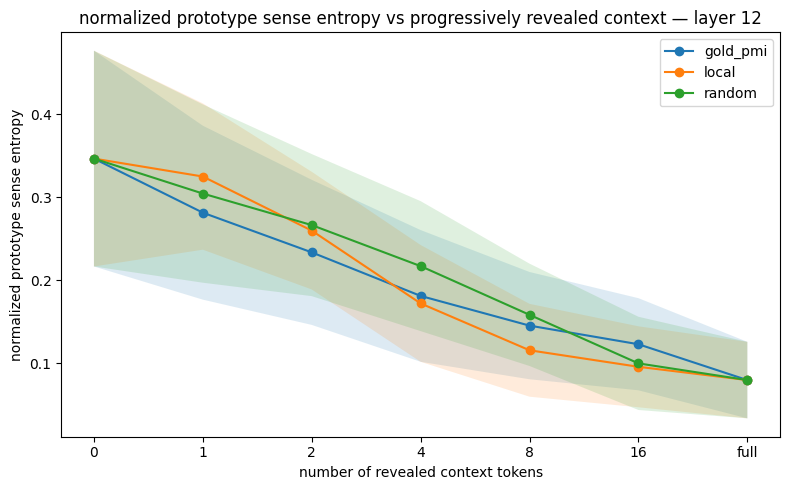

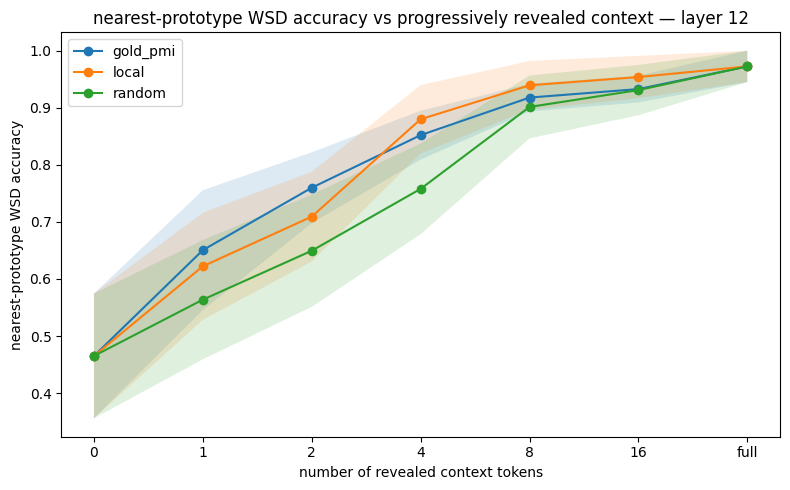

In [15]:
stage_labels = [str(k) for k in REVEAL_COUNTS] + ["full"]
stage_orders = list(range(len(stage_labels)))


def aggregate_across_words(metric, layer=MAIN_LAYER):
    g = (
        summary_metrics[
            summary_metrics["layer"] == layer
        ]
        .groupby(
            ["strategy", "stage", "stage_order"]
        )[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values(["strategy", "stage_order"])
    )

    g["sem"] = (
        g["std"] / np.sqrt(np.maximum(g["count"], 1))
    )
    return g


def plot_summary_metric(
    metric,
    ylabel,
    layer=MAIN_LAYER,
    filename=None,
):
    agg = aggregate_across_words(metric, layer)

    plt.figure(figsize=(8, 5))

    for strategy, g in agg.groupby("strategy"):
        g = g.sort_values("stage_order")

        x = g["stage_order"].to_numpy()
        y = g["mean"].to_numpy()
        e = g["sem"].fillna(0).to_numpy()

        plt.plot(
            x,
            y,
            marker="o",
            label=strategy,
        )
        plt.fill_between(
            x,
            y - e,
            y + e,
            alpha=0.15,
        )

    plt.xticks(stage_orders, stage_labels)
    plt.xlabel("number of revealed context tokens")
    plt.ylabel(ylabel)
    plt.title(
        f"{ylabel} vs progressively revealed context — layer {layer}"
    )
    plt.legend()
    plt.tight_layout()

    if filename:
        plt.savefig(
            OUTPUT_DIR / filename,
            bbox_inches="tight",
        )

    plt.show()


plot_summary_metric(
    "mean_sense_entropy",
    "normalized prototype sense entropy",
    filename="01_entropy_vs_context.png",
)

plot_summary_metric(
    "wsd_accuracy",
    "nearest-prototype WSD accuracy",
    filename="02_wsd_accuracy_vs_context.png",
)

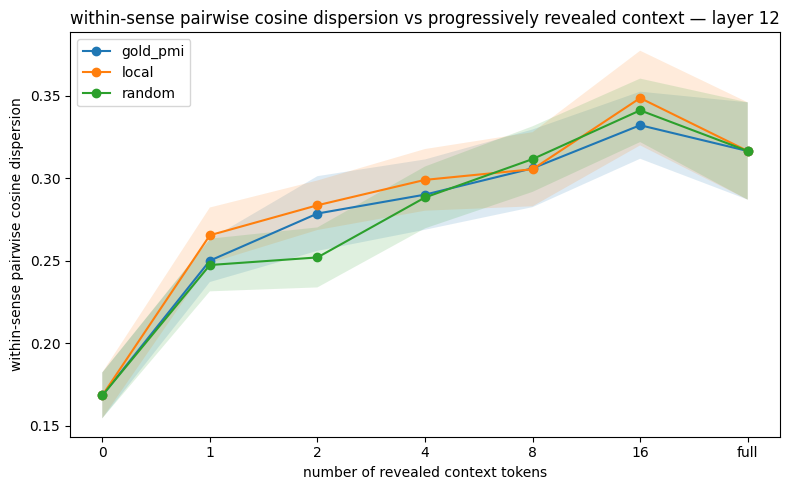

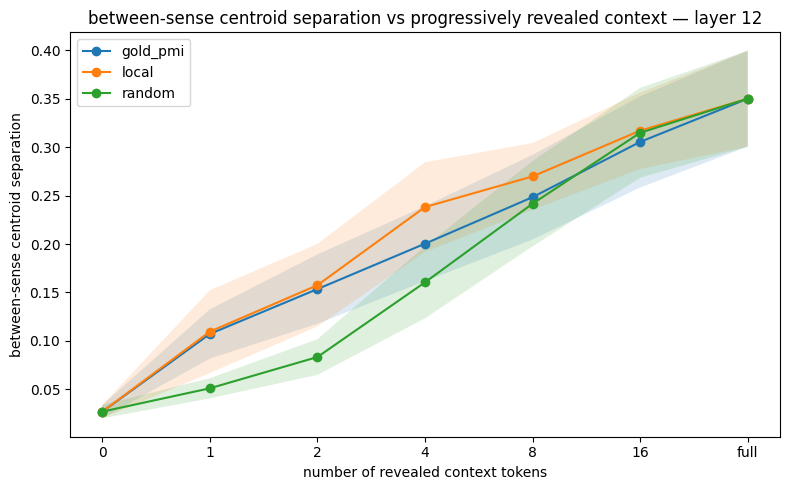

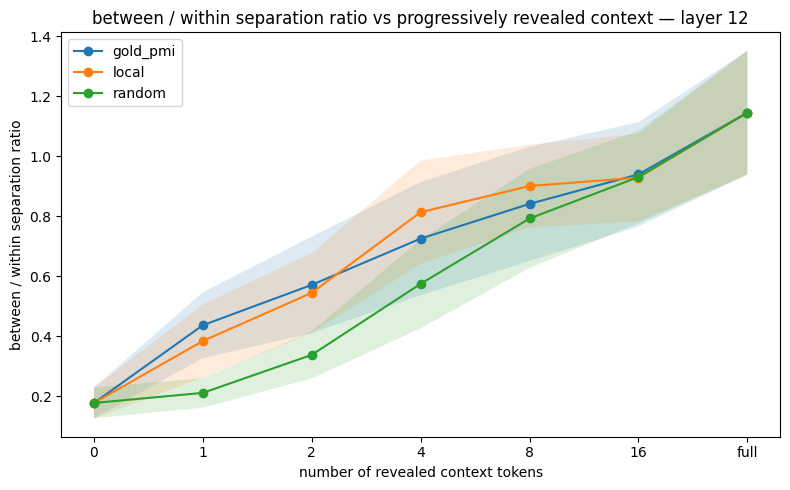

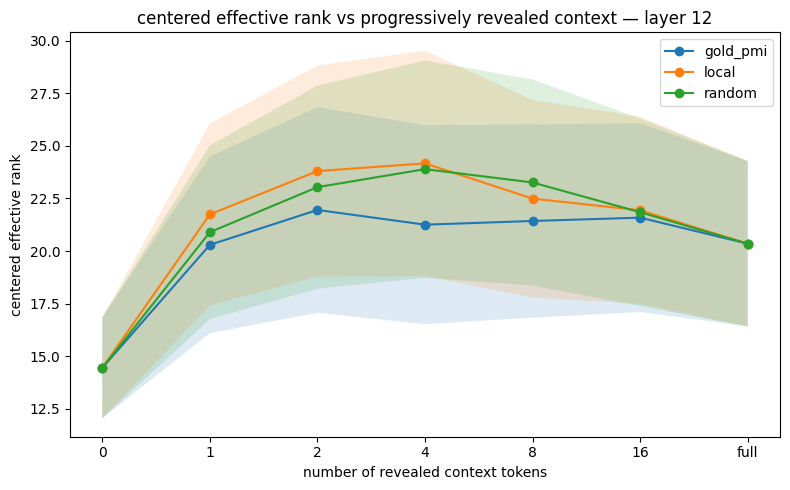

In [16]:
plot_summary_metric(
    "within_dispersion",
    "within-sense pairwise cosine dispersion",
    filename="03_within_dispersion_vs_context.png",
)

plot_summary_metric(
    "between_separation",
    "between-sense centroid separation",
    filename="04_between_separation_vs_context.png",
)

plot_summary_metric(
    "separation_ratio",
    "between / within separation ratio",
    filename="05_separation_ratio_vs_context.png",
)

plot_summary_metric(
    "effective_rank",
    "centered effective rank",
    filename="06_effective_rank_vs_context.png",
)

## Competing-hypothesis diagnostics

For `gold_pmi`, calculate per-word monotonic trends:

\[
\rho_H
=
\rho(\text{context stage}, H(S\mid C))
\]

\[
\rho_W
=
\rho(\text{context stage}, V_{\text{within}})
\]

\[
\rho_B
=
\rho(\text{context stage}, D_{\text{between}}).
\]

Descriptive interpretation:

- \(\rho_H < 0,\ \rho_W < 0\): **contraction**
- \(\rho_H < 0,\ \rho_B > 0,\ \rho_W \approx 0\): **separation**
- \(\rho_H < 0,\ \rho_B > 0,\ \rho_W > 0\): **contextual enrichment**

In [17]:
trend_records = []

main = summary_metrics[
    summary_metrics["strategy"] == "gold_pmi"
].copy()

for (word, layer), g in main.groupby(["word", "layer"]):
    g = g.sort_values("stage_order")
    x = g["stage_order"].to_numpy()

    rho_h = spearmanr(
        x,
        g["mean_sense_entropy"],
    ).statistic

    rho_w = spearmanr(
        x,
        g["within_dispersion"],
    ).statistic

    rho_b = spearmanr(
        x,
        g["between_separation"],
    ).statistic

    rho_r = spearmanr(
        x,
        g["separation_ratio"],
    ).statistic

    first = g.iloc[0]
    last = g.iloc[-1]

    dH = (
        last["mean_sense_entropy"]
        - first["mean_sense_entropy"]
    )
    dW = (
        last["within_dispersion"]
        - first["within_dispersion"]
    )
    dB = (
        last["between_separation"]
        - first["between_separation"]
    )

    tol = 0.01

    if dH < 0 and dW < -tol:
        mechanism = "contraction"
    elif dH < 0 and dW > tol and dB > 0:
        mechanism = "enrichment+separation"
    elif dH < 0 and abs(dW) <= tol and dB > 0:
        mechanism = "separation"
    elif dH < 0 and dW > tol:
        mechanism = "enrichment"
    else:
        mechanism = "mixed/no-clear-pattern"

    trend_records.append({
        "word": word,
        "layer": layer,
        "rho_entropy": rho_h,
        "rho_within": rho_w,
        "rho_between": rho_b,
        "rho_ratio": rho_r,
        "delta_entropy_0_to_full": dH,
        "delta_within_0_to_full": dW,
        "delta_between_0_to_full": dB,
        "mechanism": mechanism,
    })

trend_df = pd.DataFrame(trend_records)

display(
    trend_df[
        trend_df["layer"] == MAIN_LAYER
    ].sort_values("word")
)

,word,layer,rho_entropy,rho_within,rho_between,rho_ratio,delta_entropy_0_to_full,delta_within_0_to_full,delta_between_0_to_full,mechanism
2,bank,12,0.857143,0.964286,0.964286,0.857143,0.020699,0.333031,0.440212,mixed/no-clear-pattern
5,bass,12,-0.892857,0.964286,1.000000,1.000000,-0.125101,0.086737,0.139265,enrichment+separation
8,crane,12,-1.000000,0.964286,1.000000,0.857143,-0.613989,0.168121,0.221844,enrichment+separation
11,java,12,-0.964286,0.785714,1.000000,0.964286,-0.238752,0.039457,0.459193,enrichment+separation
14,mole,12,-1.000000,0.785714,1.000000,1.000000,-0.632497,0.107084,0.337573,enrichment+separation
17,spring,12,-0.428571,0.964286,1.000000,1.000000,-0.010407,0.154842,0.338822,enrichment+separation


In [18]:
def safe_wilcoxon(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 2 or np.allclose(values, 0):
        return np.nan

    return wilcoxon(values).pvalue


main_trends = trend_df[
    trend_df["layer"] == MAIN_LAYER
].copy()

tests = pd.DataFrame({
    "quantity": [
        "delta entropy (full - 0)",
        "delta within dispersion (full - 0)",
        "delta between separation (full - 0)",
        "rho entropy",
        "rho within",
        "rho between",
    ],
    "mean": [
        main_trends["delta_entropy_0_to_full"].mean(),
        main_trends["delta_within_0_to_full"].mean(),
        main_trends["delta_between_0_to_full"].mean(),
        main_trends["rho_entropy"].mean(),
        main_trends["rho_within"].mean(),
        main_trends["rho_between"].mean(),
    ],
    "median": [
        main_trends["delta_entropy_0_to_full"].median(),
        main_trends["delta_within_0_to_full"].median(),
        main_trends["delta_between_0_to_full"].median(),
        main_trends["rho_entropy"].median(),
        main_trends["rho_within"].median(),
        main_trends["rho_between"].median(),
    ],
    "wilcoxon_p_vs_zero": [
        safe_wilcoxon(main_trends["delta_entropy_0_to_full"]),
        safe_wilcoxon(main_trends["delta_within_0_to_full"]),
        safe_wilcoxon(main_trends["delta_between_0_to_full"]),
        safe_wilcoxon(main_trends["rho_entropy"]),
        safe_wilcoxon(main_trends["rho_within"]),
        safe_wilcoxon(main_trends["rho_between"]),
    ],
})

display(tests)

,quantity,mean,median,wilcoxon_p_vs_zero
0,delta entropy (full - 0),-0.266675,-0.181927,0.09375
1,delta within dispersion (full - 0),0.148212,0.130963,0.03125
2,delta between separation (full - 0),0.322818,0.338197,0.03125
3,rho entropy,-0.571429,-0.928571,0.09375
4,rho within,0.904762,0.964286,0.03125
5,rho between,0.994048,1.000000,0.03125


## Matched-count control: informative vs random context

At the same reveal count \(k\), compare `gold_pmi` and `random`.

The manipulation is doing what we intend if:

\[
H_{\text{gold-PMI}}(k)
<
H_{\text{random}}(k)
\]

with both exposing the same number of non-target tokens.

In [19]:
matched = summary_metrics[
    (summary_metrics["layer"] == MAIN_LAYER)
    & (summary_metrics["stage"] != "full")
    & (
        summary_metrics["strategy"]
        .isin(["gold_pmi", "random"])
    )
].copy()

pivot = matched.pivot_table(
    index=["word", "stage", "stage_order"],
    columns="strategy",
    values=[
        "mean_sense_entropy",
        "wsd_accuracy",
        "within_dispersion",
        "between_separation",
    ],
)

control_records = []

for stage in [
    str(k) for k in REVEAL_COUNTS if k > 0
]:
    if stage not in pivot.index.get_level_values("stage"):
        continue

    p = pivot.xs(stage, level="stage")

    for metric in [
        "mean_sense_entropy",
        "wsd_accuracy",
    ]:
        if (
            (metric, "gold_pmi") not in p.columns
            or (metric, "random") not in p.columns
        ):
            continue

        diff = (
            p[(metric, "gold_pmi")]
            - p[(metric, "random")]
        )

        control_records.append({
            "stage": stage,
            "metric": metric,
            "mean_gold_minus_random": diff.mean(),
            "median_gold_minus_random": diff.median(),
            "wilcoxon_p": safe_wilcoxon(diff),
            "n_words": diff.notna().sum(),
        })

control_df = pd.DataFrame(control_records)
display(control_df)

,stage,metric,mean_gold_minus_random,median_gold_minus_random,wilcoxon_p,n_words
0,1,mean_sense_entropy,-0.023013,-0.020352,0.31250,6
1,1,wsd_accuracy,0.086822,0.074170,0.06250,6
2,2,mean_sense_entropy,-0.032829,-0.051780,0.31250,6
3,2,wsd_accuracy,0.110395,0.128345,0.15625,6
4,4,mean_sense_entropy,-0.035875,-0.041176,0.31250,6
5,4,wsd_accuracy,0.094173,0.138971,0.21875,6
6,8,mean_sense_entropy,-0.013005,-0.028520,0.43750,6
7,8,wsd_accuracy,0.016427,0.014877,0.68750,6
8,16,mean_sense_entropy,0.023046,0.001158,0.84375,6
9,16,wsd_accuracy,0.001726,-0.013158,0.87500,6


## 2D geometry for one ambiguous word

A single PCA basis is fit across the selected stages so the axes remain comparable.

This is exploratory visualization only; the quantitative claims use the original high-dimensional vectors.

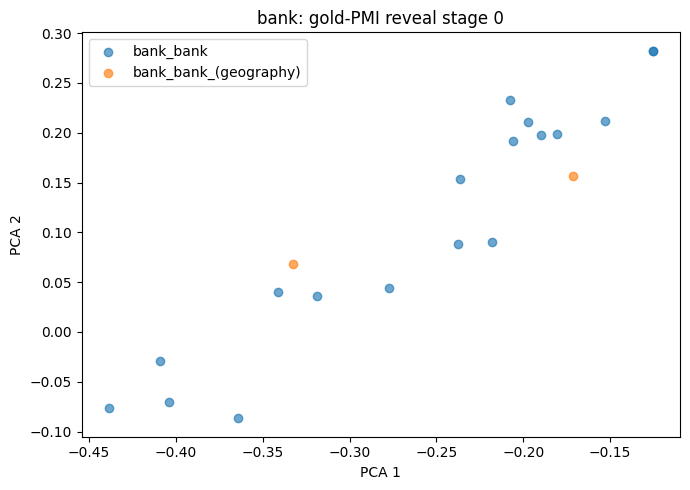

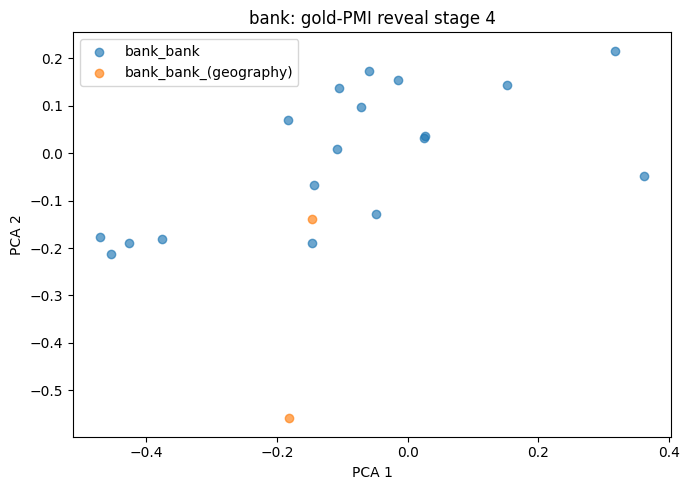

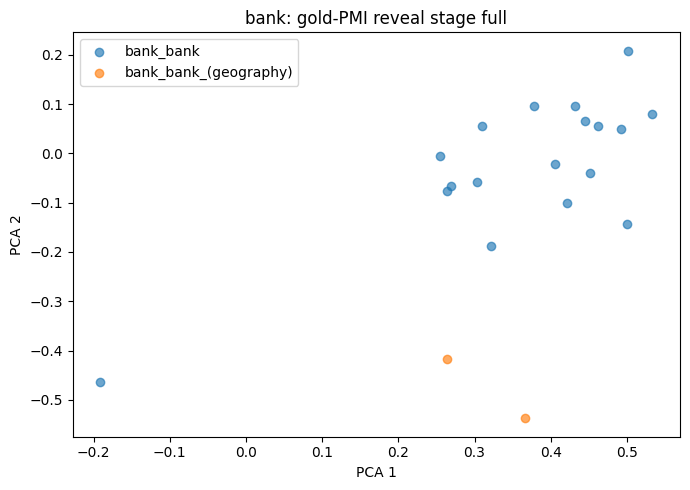

In [20]:
PLOT_WORD = "bank" if "bank" in WORDS else WORDS[0]
PLOT_STAGES = ["0", "4", "full"]

mask = (
    (variant_df["word"] == PLOT_WORD)
    & (variant_df["strategy"] == "gold_pmi")
    & (variant_df["stage"].isin(PLOT_STAGES))
)

idxs = np.where(mask.to_numpy())[0]
x = variant_embeddings[MAIN_LAYER][idxs]

meta = (
    variant_df.iloc[idxs]
    .copy()
    .reset_index(drop=True)
)

pca = PCA(
    n_components=2,
    random_state=SEED,
)
xy = pca.fit_transform(x)

meta["pc1"] = xy[:, 0]
meta["pc2"] = xy[:, 1]

sense_names = sorted(
    meta["sense_name"].unique()
)

for stage in PLOT_STAGES:
    g = meta[meta["stage"] == stage]

    plt.figure(figsize=(7, 5))

    for sense in sense_names:
        s = g[g["sense_name"] == sense]
        plt.scatter(
            s["pc1"],
            s["pc2"],
            alpha=0.65,
            label=sense,
        )

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(
        f"{PLOT_WORD}: gold-PMI reveal stage {stage}"
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / f"pca_{PLOT_WORD}_stage_{stage}.png",
        bbox_inches="tight",
    )

    plt.show()

## Layer sanity check

The independent variable is context evidence, not Transformer depth.

Still, prior work shows lexical disambiguation changes across layers. Since layers 4, 8, and 12 were cached in one pass, we verify that any phenomenon is not unique to the final layer.

,layer,rho_entropy,rho_within,rho_between,delta_entropy_0_to_full,delta_within_0_to_full,delta_between_0_to_full
0,4,-0.363095,0.982143,0.994048,-0.238631,0.140622,0.208886
1,8,-0.541667,0.666667,0.976190,-0.234762,0.120392,0.263171
2,12,-0.571429,0.904762,0.994048,-0.266675,0.148212,0.322818


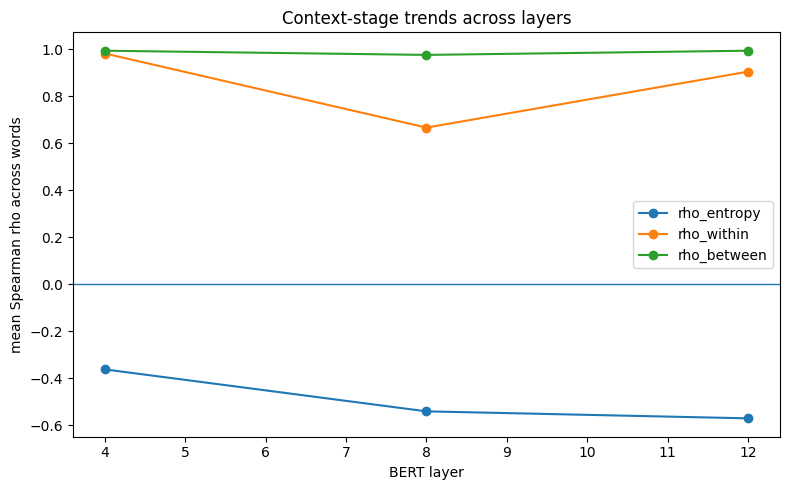

In [21]:
layer_summary = (
    trend_df.groupby("layer")[[
        "rho_entropy",
        "rho_within",
        "rho_between",
        "delta_entropy_0_to_full",
        "delta_within_0_to_full",
        "delta_between_0_to_full",
    ]]
    .mean()
    .reset_index()
)

display(layer_summary)

plt.figure(figsize=(8, 5))

for metric in [
    "rho_entropy",
    "rho_within",
    "rho_between",
]:
    plt.plot(
        layer_summary["layer"],
        layer_summary[metric],
        marker="o",
        label=metric,
    )

plt.axhline(0, linewidth=1)
plt.xlabel("BERT layer")
plt.ylabel("mean Spearman rho across words")
plt.title("Context-stage trends across layers")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "07_layer_sanity_check.png",
    bbox_inches="tight",
)
plt.show()

## Interpretation template

Do **not** choose the story before looking at the curves.

### A — contraction

\[
H\downarrow,\qquad V_{\text{within}}\downarrow
\]

The original “meaning region shrinks” intuition receives support.

### B — separation

\[
H\downarrow,\qquad
D_{\text{between}}\uparrow,\qquad
V_{\text{within}}\approx\text{constant}
\]

Context resolves ambiguity mainly by separating alternatives.

### C — contextual enrichment

\[
H\downarrow,\qquad
V_{\text{within}}\uparrow
\]

while separation/WSD quality improves.

The interesting claim becomes:

> semantic certainty can increase while geometric diversity also increases.

### D — no stable pattern

If effects differ wildly across words/layers or the `gold_pmi` manipulation is not reliably more informative than random context, improve the controlled stimuli rather than adding a neural architecture.

## Robustness extensions — only if the pilot is interesting

Recommended order:

1. all 20 CoarseWSD-20 words (`RUN_MODE="full"`);
2. `roberta-base`;
3. natural, non-masked context growth;
4. RAW-C / human-graded ambiguity;
5. bootstrap confidence intervals over **words**, not just instances;
6. synthetic minimal pairs with tightly controlled syntax and token count;
7. if semantic breadth becomes a main claim, implement the alignment/statistical precautions motivated by Ehara (ACL 2026).

Do not add an MLP unless the geometry itself first produces a nontrivial phenomenon.

In [22]:
# Save quantitative outputs.

instance_metrics.to_parquet(
    OUTPUT_DIR / "instance_metrics.parquet",
    index=False,
)

summary_metrics.to_csv(
    OUTPUT_DIR / "summary_metrics.csv",
    index=False,
)

trend_df.to_csv(
    OUTPUT_DIR / "per_word_trends.csv",
    index=False,
)

control_df.to_csv(
    OUTPUT_DIR / "matched_context_controls.csv",
    index=False,
)

tests.to_csv(
    OUTPUT_DIR / "aggregate_tests.csv",
    index=False,
)

config = {
    "run_mode": RUN_MODE,
    "dataset": DATASET_ID,
    "model": MODEL_NAME,
    "words": WORDS,
    "layers": LAYERS_TO_SAVE,
    "main_layer": MAIN_LAYER,
    "reveal_counts": REVEAL_COUNTS,
    "strategies": STRATEGIES,
    "seed": SEED,
    "max_train_per_sense": MAX_TRAIN_PER_SENSE,
    "max_test_per_sense": MAX_TEST_PER_SENSE,
}

with open(
    OUTPUT_DIR / "config.json",
    "w",
) as f:
    json.dump(config, f, indent=2)

print("saved to:", OUTPUT_DIR.resolve())
print(
    sorted(p.name for p in OUTPUT_DIR.iterdir())
)

saved to: /kaggle/working/semantic_disambiguation_geometry_outputs
['01_entropy_vs_context.png', '02_wsd_accuracy_vs_context.png', '03_within_dispersion_vs_context.png', '04_between_separation_vs_context.png', '05_separation_ratio_vs_context.png', '06_effective_rank_vs_context.png', '07_layer_sanity_check.png', 'aggregate_tests.csv', 'config.json', 'instance_metrics.parquet', 'matched_context_controls.csv', 'pca_bank_stage_0.png', 'pca_bank_stage_4.png', 'pca_bank_stage_full.png', 'per_word_trends.csv', 'summary_metrics.csv']


In [23]:
# Pack results for Kaggle download.
import shutil

archive = shutil.make_archive(
    "semantic_disambiguation_geometry_results",
    "zip",
    root_dir=OUTPUT_DIR,
)

print("archive:", archive)

archive: /kaggle/working/semantic_disambiguation_geometry_results.zip


## Stop / continue criterion

Escalate beyond a pilot only if most of these hold:

- `gold_pmi` is measurably more disambiguating than matched-count random context;
- uncertainty decreases consistently across several ambiguous words;
- geometry shows a repeatable mechanism: contraction, separation, enrichment, or a meaningful mixture;
- the effect survives another layer/model family;
- the result is not purely a `[MASK]` artifact;
- interpretation is anchored to gold senses or human judgments.

If the only result is “full context improves WSD accuracy”, stop — that is already known.